# 5. Spline templates and nuisance-profiled fits


    Replace repeated histogram filling with a parameterized template model.
    Compare spline predictions with independent construction-parameter anchors,
    then compare direct binned, spline binned, and unbinned profiled scans.
    Run notebooks 1–4 first.

### Runtime and persistent run

In Colab, choose **Runtime → Change runtime type → GPU** for notebooks 2–3.
Both PyTorch training and JAX likelihood fits use the GPU when available.
`JAX_BACKEND = "auto"` detects the Colab NVIDIA GPU; choose `"gpu"` to require it,
or `"cpu"` for an explicit CPU run. Setup installs matching JAX/JAXlib and CUDA 12
plugin packages, then checks double-precision JIT computation and gradients on
the selected device before training. GPU initialization failures are reported
instead of silently switching to CPU. Restart the runtime once when switching
from the previous CPU-only setup or after a JAX plugin error.
For a runtime-only repair, keep the same run name: saved samples and trained
networks are reused. A changed physics model requires a new run, as below.
The source checkout lives in the temporary runtime; **datasets, checkpoints,
workspace files, and results live in Google Drive**. Use the same `RUN_NAME`
and `MODE` in every notebook. Set `MODE = "smoke"` for a short workflow check;
the production default generates five million events **per sample**.
Use `CONFIG_OVERRIDES` to change a computational budget without editing source,
for example `{"quadrature_per_process": 500_000, "epochs": 150}`. Use the same
overrides in all five notebooks, and choose a new `RUN_NAME` when changing them.

This repository may be private. Grant Colab access when opening it from GitHub.
For the runtime download, either save a GitHub fine-grained token with **Contents:
read** access to this repository as the Colab secret `GITHUB_TOKEN`, or enter it
in the hidden prompt. The token is used only in a Python HTTP header and is not
written into files, Git remotes, shell arguments, or notebook output. Alternatively,
upload a repository ZIP to `/content/poodemo_source.zip`; no token is then needed.
An existing `/content/poodemo` checkout is reused. Delete that checkout to fetch
new source after updating the repository; your Drive run is separate.
For the nearby-minimum benchmark, use the new default
`RUN_NAME = "paper-nearby-v2"` and rerun notebooks 1–5.
If you ran an earlier version, start a fresh Colab runtime (or refresh the
temporary source checkout and restart the runtime) before proceeding. Existing
run manifests from the earlier physics model are incompatible and are not
reused. The new run keeps those earlier Drive files intact.

In [1]:
import os
import sys
from pathlib import Path

RUN_NAME = "paper-nearby-v2"
MODE = os.environ.get("POODEMO_MODE", "production")  # production or smoke
CONFIG_OVERRIDES = {}  # e.g. {"quadrature_per_process": 500_000, "epochs": 150}
JAX_BACKEND = os.environ.get("POODEMO_JAX_BACKEND", "auto")  # auto, gpu, or cpu

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    requested_backend = JAX_BACKEND.strip().lower()
    if requested_backend not in ("auto", "gpu", "cpu"):
        raise ValueError("JAX_BACKEND must be auto, gpu, or cpu")
    selected_backend = requested_backend
    if requested_backend == "auto":
        try:
            gpu_probe = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                                       capture_output=True, text=True, timeout=10)
            gpu_present = gpu_probe.returncode == 0 and bool(gpu_probe.stdout.strip())
        except (OSError, subprocess.TimeoutExpired):
            gpu_present = False
        selected_backend = "gpu" if gpu_present else "cpu"
    # CUDA-only selection fails visibly if initialization fails. Keep PyTorch's
    # CUDA visibility and avoid JAX reserving most GPU memory before training.
    jax_platform = "cuda" if selected_backend == "gpu" else "cpu"
    os.environ["JAX_PLATFORMS"] = jax_platform
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    ROOT = Path(os.environ.get("POODEMO_ROOT", f"/content/drive/MyDrive/poodemo/runs/{RUN_NAME}"))
    REPO_DIR = Path("/content/poodemo")
    if not (REPO_DIR / "pyproject.toml").exists():
        import getpass
        import io
        import shutil
        import tarfile
        import tempfile
        import urllib.error
        import urllib.request
        import zipfile

        uploaded_zip = Path("/content/poodemo_source.zip")
        if uploaded_zip.exists():
            archive_bytes = uploaded_zip.read_bytes()
            archive_kind = "zip"
        else:
            archive_url = "https://api.github.com/repos/rafaellopesdesa/poodemo/tarball/main"

            def fetch_source(token=None):
                headers = {"Accept": "application/vnd.github+json", "User-Agent": "poodemo-colab"}
                if token:
                    headers["Authorization"] = "Bearer " + token
                request = urllib.request.Request(archive_url, headers=headers)
                with urllib.request.urlopen(request, timeout=180) as response:
                    return response.read()

            try:
                archive_bytes = fetch_source()
            except urllib.error.HTTPError as error:
                if error.code not in (401, 403, 404):
                    raise RuntimeError(f"Repository download failed (HTTP {error.code}).") from None
                token = None
                try:
                    from google.colab import userdata
                    token = userdata.get("GITHUB_TOKEN")
                except Exception:
                    pass
                if not token:
                    token = getpass.getpass("GitHub token with read access to poodemo: ").strip()
                if not token:
                    raise RuntimeError("Upload /content/poodemo_source.zip or provide read access.")
                try:
                    archive_bytes = fetch_source(token)
                except urllib.error.HTTPError as auth_error:
                    raise RuntimeError(f"Repository download failed (HTTP {auth_error.code}); check token access.") from None
                finally:
                    token = None
            archive_kind = "tar"

        # Validate archive paths and reject links before extracting the source.
        with tempfile.TemporaryDirectory(prefix="poodemo-source-") as temp:
            staging = Path(temp).resolve()

            def safe_destination(name):
                destination = (staging / name).resolve()
                if not destination.is_relative_to(staging):
                    raise RuntimeError("Unsafe path in source archive.")
                return destination

            if archive_kind == "zip":
                with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
                    for entry in archive.infolist():
                        safe_destination(entry.filename)
                        if (entry.external_attr >> 16) & 0o170000 == 0o120000:
                            raise RuntimeError("Symbolic links are not supported in the source ZIP.")
                    archive.extractall(staging)
            else:
                with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:gz") as archive:
                    for entry in archive.getmembers():
                        safe_destination(entry.name)
                        if not (entry.isfile() or entry.isdir()):
                            raise RuntimeError("Links and special files are not supported in the source archive.")
                    archive.extractall(staging)
            candidates = [p.parent for p in staging.rglob("pyproject.toml") if (p.parent / "poodemo").is_dir()]
            if len(candidates) != 1:
                raise RuntimeError("The uploaded archive must contain one poodemo repository checkout.")
            shutil.copytree(candidates[0], REPO_DIR, dirs_exist_ok=True)
        del archive_bytes

    if os.environ.get("POODEMO_SKIP_INSTALL") != "1":
        from importlib.metadata import version, PackageNotFoundError
        # JAX discovers every installed plugin, even when selecting CPU.
        # Retain already-matched CUDA 12 packages when rerunning GPU setup.
        remove_plugins = []
        for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt", "jax-cuda13-plugin", "jax-cuda13-pjrt"):
            try:
                installed_version = version(package)
            except PackageNotFoundError:
                continue
            if not (selected_backend == "gpu" and package.startswith("jax-cuda12-") and installed_version == "0.5.3"):
                remove_plugins.append(package)
        if remove_plugins:
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", *remove_plugins])
        gpu_requirements = (["jax==0.5.3", "jaxlib==0.5.3",
                             "jax-cuda12-plugin[with-cuda]==0.5.3", "jax-cuda12-pjrt==0.5.3"]
                            if selected_backend == "gpu" else [])
        # Resolve with the base requirements so PyTorch's CUDA dependencies are
        # considered together with JAX's. Avoid blanket --upgrade changes.
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r",
                               str(REPO_DIR / "requirements-colab.txt"), *gpu_requirements])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)])

        # Check the live notebook kernel before any expensive network training.
        import jax
        import jaxlib
        import jax.numpy as jnp
        if jax.__version__ != "0.5.3" or jaxlib.__version__ != "0.5.3":
            raise RuntimeError("JAX packages are stale in this kernel. Restart the runtime and rerun setup.")
        if selected_backend == "gpu":
            for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt"):
                if version(package) != "0.5.3":
                    raise RuntimeError(f"{package} must match JAX 0.5.3. Restart the runtime and rerun setup.")
        jax.config.update("jax_platforms", jax_platform)
        jax.config.update("jax_enable_x64", True)
        try:
            jax_devices = jax.devices()
            if not jax_devices or any(device.platform != selected_backend for device in jax_devices):
                raise RuntimeError(f"Expected {selected_backend} devices; found {jax_devices}")
            probe_value, probe_gradient = jax.jit(jax.value_and_grad(lambda x: jnp.sum(x*x)))(
                jnp.asarray([1., 2., 3.], dtype=jnp.float64))
            probe_gradient.block_until_ready()
            if (float(probe_value) != 14. or list(probe_gradient) != [2., 4., 6.]
                    or probe_gradient.dtype != jnp.float64
                    or any(device.platform != selected_backend for device in probe_gradient.devices())):
                raise RuntimeError("JAX double-precision value/gradient check failed")
        except Exception as error:
            raise RuntimeError(
                f"JAX {selected_backend} startup failed. Select a Colab GPU runtime if requesting GPU, "
                "then restart the runtime and rerun setup. Use JAX_BACKEND='cpu' only for an intentional CPU run."
            ) from error
        print(f"JAX {jax.__version__} / jaxlib {jaxlib.__version__}: backend={selected_backend}, {jax_devices}; float64 JIT/gradient OK")

    # A new editable install is not activated in an already-running kernel.
    # Expose the inner package directly, including after a failed import cached
    # the outer /content/poodemo checkout as a namespace package.
    import importlib
    source_root = str(REPO_DIR.resolve())
    if source_root in sys.path:
        sys.path.remove(source_root)
    sys.path.insert(0, source_root)
    importlib.invalidate_caches()
    cached_package = sys.modules.get("poodemo")
    cached_file = getattr(cached_package, "__file__", None)
    expected_init = REPO_DIR / "poodemo" / "__init__.py"
    if cached_package is not None and (cached_file is None or Path(cached_file).resolve() != expected_init.resolve()):
        for module_name in list(sys.modules):
            if module_name == "poodemo" or module_name.startswith("poodemo."):
                del sys.modules[module_name]
else:
    # Locally: pip install -r requirements-colab.txt && pip install -e .
    ROOT = Path(os.environ.get("POODEMO_ROOT", str(Path.home() / "poodemo-runs" / RUN_NAME)))
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "poodemo" / "pipeline.py").exists():
            sys.path.insert(0, str(candidate))
            break

ROOT.mkdir(parents=True, exist_ok=True)
print(f"Run directory: {ROOT}")
print(f"Mode: {MODE}")

Mounted at /content/drive


/tmp/ipykernel_2356/973191171.py:110: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(staging)


JAX 0.5.3 / jaxlib 0.5.3: backend=gpu, [CudaDevice(id=0)]; float64 JIT/gradient OK
Run directory: /content/drive/MyDrive/poodemo/runs/paper-nearby-v2
Mode: production


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from poodemo.pipeline import create_run

run = create_run(ROOT, mode=MODE, overrides=CONFIG_OVERRIDES)
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.2})
display(pd.Series(run.config, name="configuration"))

,configuration
schema_version,5
mode,production
seed,20261006
physics_overrides,{}
toolkit_commit,fc09848fc6540fd32310faebbe9db6eea7ecd17b
n_per_sample,5000000
generation_chunk,250000
preselection_train_cap,1000000
ratio_train_cap,2000000
epochs,100


### The spline coordinate is the construction parameter \(\eta\)

A process yield \(H_{jb}(\eta)\) in a fixed \(z\)-bin changes when
\(\eta\) changes because the observable moves events between bins.
The physical \(\mu\)-dependence still enters through the exact amplitude
coefficients. These two roles must stay separate:
\[
\nu_b(\mu;\eta)=(\mu-\sqrt\mu)H_{Sb}(\eta)
+\sqrt\mu H_{SBI,b}(\eta)+(1-\sqrt\mu)H_{Bb}(\eta)
+H_{NI,b}(\eta).
\]
Since the selected phase space is fixed and bins are exhaustive,
\(\sum_bH_{jb}(\eta)=\lambda_j\) is independent of \(\eta\).
We interpolate bin fractions with positivity and normalization enforced,
then restore the separate total yield. SBI interference enters through
the coherent templates, not an independently generated signed sample.

### Vary the templates, then interpolate the nuisance

Build nominal and ±1 templates for NI and nominal templates for S, B,
and SBI. Fit their dependence on \(\eta\).
At any construction point, evaluate the splines first; then use the
same exponential–polynomial rule to interpolate in \(\alpha_{NI}\).
Every profiled fit retains the Gaussian auxiliary constraint
\(\exp(-\alpha_{NI}^2/2)\), or \(+\alpha_{NI}^2\) in \(-2\log L\).

The Asimov data histogram also depends on \(\eta\) and is refilled from
the integration events at each tested point, rather than interpolated.
All nuisance fits keep \(\eta=\mu_0\) fixed
in both numerator and denominator.

Integration and nonlinear nuisance interpolation generally do not
commute:
\[
\int_{B_b(\eta)}\!\mathrm{Interp}_{\alpha_{NI}}[D(x)]\,dx
\ne \mathrm{Interp}_{\alpha_{NI}}\!\left[\int_{B_b(\eta)}D(x)\,dx\right].
\]
This difference is recorded separately from spline interpolation error.
Agreement at nominal and ±1 templates alone does not establish equality
between the continuously morphed unbinned and binned models.

In [3]:
from poodemo.pipeline import run_spline_study

splines = run_spline_study(run, n_bins=20)
display(splines['validation'])
display(splines['yields'])

Spline and direct profile fits at eta=0.2 ready
Spline and direct profile fits at eta=0.215 ready
Spline and direct profile fits at eta=0.23 ready
Spline and direct profile fits at eta=0.244 ready
Spline and direct profile fits at eta=0.259 ready
Spline and direct profile fits at eta=0.274 ready
Spline and direct profile fits at eta=0.289 ready
Spline and direct profile fits at eta=0.304 ready
Spline and direct profile fits at eta=0.319 ready
Spline and direct profile fits at eta=0.333 ready
Spline and direct profile fits at eta=0.348 ready
Spline and direct profile fits at eta=0.363 ready
Spline and direct profile fits at eta=0.378 ready
Spline and direct profile fits at eta=0.393 ready
Spline and direct profile fits at eta=0.407 ready
Spline and direct profile fits at eta=0.422 ready
Spline and direct profile fits at eta=0.437 ready
Spline and direct profile fits at eta=0.452 ready
Spline and direct profile fits at eta=0.467 ready
Spline and direct profile fits at eta=0.481 ready
Spl

,eta,sample,variation,max_fraction_error,l1_fraction_error
0,0.20025,S,nominal,0.000032,0.000187
1,0.20025,SBI,nominal,0.000033,0.000191
2,0.20025,B,nominal,0.000033,0.000191
3,0.20025,NI,nominal,0.000040,0.000214
4,0.20025,S,NI_down,0.000032,0.000187
...,...,...,...,...,...
43207,1.39975,NI,NI_down,0.000042,0.000143
43208,1.39975,S,NI_up,0.000023,0.000109
43209,1.39975,SBI,NI_up,0.000023,0.000109
43210,1.39975,B,NI_up,0.000023,0.000109


,eta,sample,variation,bin,yield_value
0,0.2,S,nominal,0,115535.882902
1,0.2,S,nominal,1,5517.950862
2,0.2,S,nominal,2,3274.718721
3,0.2,S,nominal,3,2420.919744
4,0.2,S,nominal,4,1954.213837
...,...,...,...,...,...
864475,1.4,NI,NI_up,15,48212.847237
864476,1.4,NI,NI_up,16,50703.034180
864477,1.4,NI,NI_up,17,56151.480188
864478,1.4,NI,NI_up,18,63272.901083


We use **20 bins** explicitly, matching the finest resolution in notebook 4.
The saved binning diagnostic reports the retained extended Fisher information
across the tested anchors, including whether this choice reaches 99% at every
anchor. The splines are shape-preserving piecewise cubic
Hermite interpolants (PCHIP) of nonnegative bin fractions, followed by
explicit normalization. This preserves zero-valued anchors without a
logarithmic floor. Queries that differ from an anchor only by
floating-point roundoff reuse its stored bin fractions, so nominal
and varied templates keep their exact empty-bin support. No
extrapolation beyond the anchor range is permitted.

The score can change rapidly as \(\eta\) crosses the interference
turnover, moving expected yields between fixed bins. The spline grid
therefore combines uniform anchors over the scan range with a focused
grid around the turnover calculated from **expected nominal yields**.
Production uses 2,401 uniform anchors and 1,201 focused anchors within
\(\pm0.1\) of that point; smoke mode uses 241 and 121. The generating
value is included, duplicates are removed, and the focused interval is
clipped to the scan range. These settings are configurable through
`spline_anchors`, `spline_focus_anchors`, and `spline_focus_halfwidth`.

The extra anchors use no observed fluctuations or fitted scan values.
Their density addresses rapid observable changes, but cannot eliminate
finite integration noise or guarantee a small likelihood error. The
template-validation table compares predictions with direct histograms
at intermediate points not used as spline anchors.
The default 82-point production scan also differs from the uniform
spline grid, so most scan points directly test likelihood interpolation.
The comparison table's `is_spline_anchor` flag identifies coincident
points and the included generating value; the shorter smoke scan is
primarily a workflow check.

,eta,sample,variation,bin,yield_value
0,0.2,S,nominal,0,115535.882902
1,0.2,S,nominal,1,5517.950862
2,0.2,S,nominal,2,3274.718721
3,0.2,S,nominal,3,2420.919744
4,0.2,S,nominal,4,1954.213837
5,0.2,S,nominal,5,1630.373792
6,0.2,S,nominal,6,1492.953781
7,0.2,S,nominal,7,1347.841638
8,0.2,S,nominal,8,1296.633756
9,0.2,S,nominal,9,1264.904475


/tmp/ipykernel_2356/345960709.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (variation, bin_number), values in subset.groupby(["variation", "bin"], sort=False):
/tmp/ipykernel_2356/345960709.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (variation, bin_number), values in subset.groupby(["variation", "bin"], sort=False):
/tmp/ipykernel_2356/345960709.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

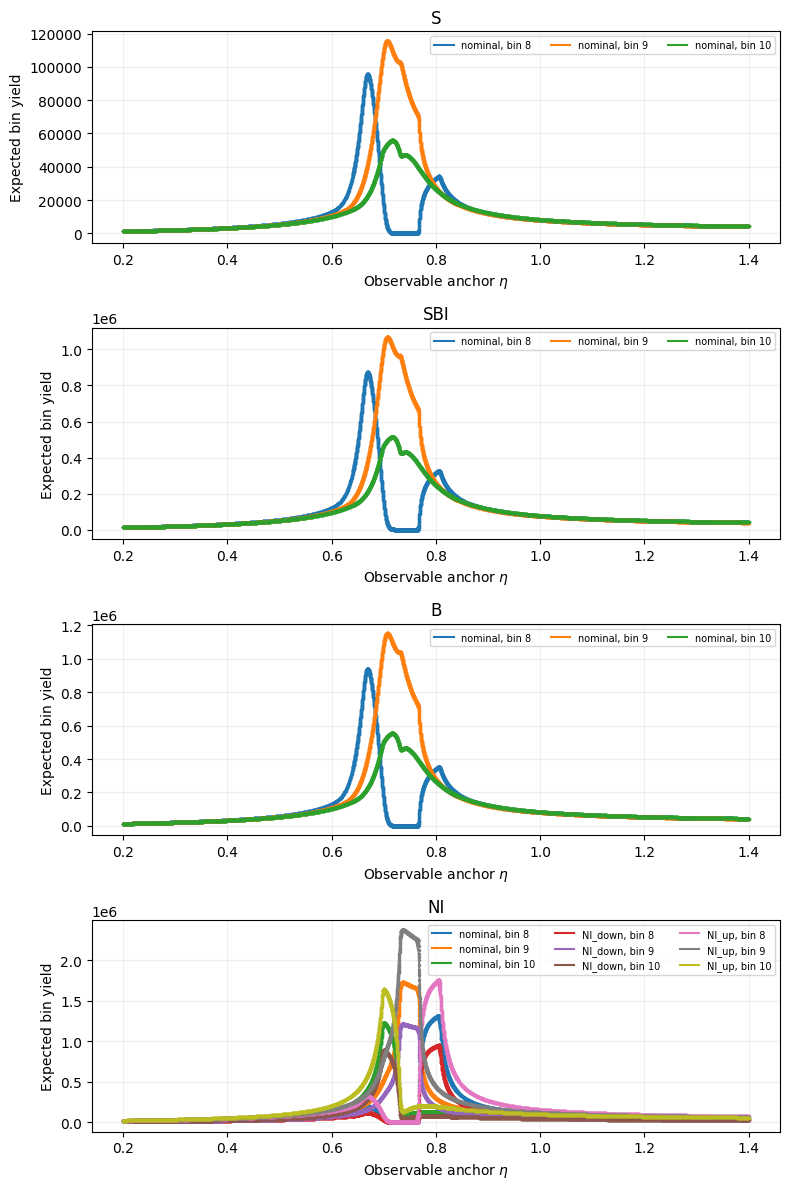

In [4]:
from poodemo.data import PROCESSES

yields = splines["yields"]
display(yields.head(20))
# Points are histogram anchors; lines are interpolated expected yields.
spline = splines["spline"]
eta_dense = np.linspace(spline.etas[0], spline.etas[-1], 200)
dense_yields = spline(eta_dense)
variation_order = ["nominal", "NI_down", "NI_up"]
processes = list(yields["sample"].unique())
fig, axes = plt.subplots(len(processes), 1, figsize=(8, 3 * len(processes)), squeeze=False)
for process, ax in zip(processes, axes[:, 0]):
    subset = yields[yields["sample"] == process]
    shown_bins = subset.groupby("bin")["yield_value"].sum().nlargest(3).index
    variations = ["nominal"] + (["NI_down", "NI_up"] if process == "NI" else [])
    subset = subset[subset["bin"].isin(shown_bins) & subset["variation"].isin(variations)]
    for (variation, bin_number), values in subset.groupby(["variation", "bin"], sort=False):
        values = values.sort_values("eta")
        curve = dense_yields[:, variation_order.index(variation), PROCESSES.index(process), int(bin_number)]
        line, = ax.plot(eta_dense, curve, label=f"{variation}, bin {bin_number}")
        ax.plot(values["eta"], values["yield_value"], ".", ms=3, color=line.get_color())
    ax.set(xlabel=r"Observable anchor $\eta$", ylabel="Expected bin yield", title=process)
    ax.legend(fontsize=7, ncol=3)
fig.tight_layout()
(ROOT / "plots").mkdir(exist_ok=True)
fig.savefig(ROOT / "plots" / "05_template_yields.pdf", bbox_inches="tight")
plt.show()

For comparison, the next plot fixes \(\eta=\mu_*\) and varies the **physical**
\(\mu\). This dependence comes from the signal/interference coefficients,
not from the spline. The two plots answer different questions.

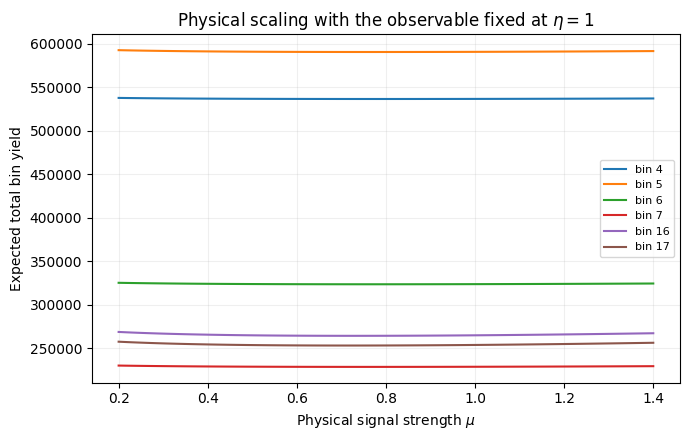

In [5]:
physical = splines["physical_yields"]
shown_bins = physical.groupby("bin")["yield_value"].sum().nlargest(6).index
fig, ax = plt.subplots()
for bin_number, values in physical[physical["bin"].isin(shown_bins)].groupby("bin"):
    ax.plot(values["mu"], values["yield_value"], label=f"bin {bin_number}")
ax.set(xlabel=r"Physical signal strength $\mu$", ylabel="Expected total bin yield",
       title=fr"Physical scaling with the observable fixed at $\eta={run.config['asimov_mu']:g}$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(ROOT / "plots" / "05_physical_bin_yields.pdf", bbox_inches="tight")
plt.show()

In [6]:
def plot_scans(frame, title, filename, group_columns=None, *, xlim=None, ylim=None):
    """Plot saved scans with optional (min, max) axis limits.

    Omit xlim/ylim to retain the default view. A None endpoint keeps that
    bound unchanged, for example ylim=(0, None) or xlim=(None, 1.2).
    """
    x_column = next((c for c in ["mu", "mu_test", "mu0"] if c in frame.columns), None)
    y_column = next((c for c in ["q", "t_mu", "test_statistic", "ts"] if c in frame.columns), None)
    if x_column is None or y_column is None:
        raise ValueError(f"Expected mu and q scan columns; found {list(frame.columns)}")
    if group_columns is None:
        group_columns = [c for c in ["method", "model", "systematics", "nuisances", "n_bins", "bins", "observable"] if c in frame.columns]
    groups = frame.groupby(group_columns, dropna=False, sort=False) if group_columns else [("scan", frame)]
    fig, ax = plt.subplots()
    for label, group in groups:
        group = group.sort_values(x_column)
        values = label if isinstance(label, tuple) else (label,)
        parts = []
        for column, value in zip(group_columns, values):
            if pd.isna(value):
                continue
            if column == "systematics":
                parts.append("profiled" if value else "stat only")
            elif column in ("n_bins", "bins"):
                parts.append(f"{int(value)} bins")
            else:
                parts.append(str(value))
        ax.plot(group[x_column], group[y_column], marker=".", ms=3, label=" | ".join(parts))
    ax.axhline(1.0, color="0.45", ls=":", lw=1)
    ax.set(xlabel=r"Tested signal strength $\mu_0$", ylabel=r"$t(\mu_0)$", title=title)
    ax.set_ylim(bottom=0)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(fontsize=8)
    fig.tight_layout()
    output = ROOT / "plots"
    output.mkdir(exist_ok=True)
    fig.savefig(output / filename, bbox_inches="tight")
    plt.show()
    return fig

,mu,model,systematics,q,valid,mu_hat,alpha_NI,fit_message,eta,n_bins,asimov_source,asimov_mu,edm
0,0.200000,direct score histogram,False,290.311376,True,1.0,0.000000,No free parameters; Converged bracketed scalar...,0.200000,20.0,NaN,NaN,NaN
1,0.200000,direct score histogram,True,185.400301,True,1.0,-0.027944,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.200000,20.0,NaN,NaN,NaN
2,0.200000,spline score histogram,False,290.311376,True,1.0,0.000000,No free parameters; Converged bracketed scalar...,0.200000,20.0,NaN,NaN,NaN
3,0.200000,spline score histogram,True,185.400301,True,1.0,-0.027944,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.200000,20.0,NaN,NaN,NaN
4,0.214815,direct score histogram,False,241.759325,True,1.0,0.000000,No free parameters; Converged bracketed scalar...,0.214815,20.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
815,1.340741,learned unbinned (model Asimov),True,54.297852,True,NaN,-0.010624,NaN,NaN,NaN,learned model,1.0,6.415460e-12
816,1.355556,learned unbinned (model Asimov),True,60.356990,True,NaN,-0.011223,NaN,NaN,NaN,learned model,1.0,6.799784e-12
817,1.370370,learned unbinned (model Asimov),True,66.829859,True,NaN,-0.011832,NaN,NaN,NaN,learned model,1.0,7.184336e-12
818,1.385185,learned unbinned (model Asimov),True,73.728735,True,NaN,-0.012450,NaN,NaN,NaN,learned model,1.0,7.569798e-12


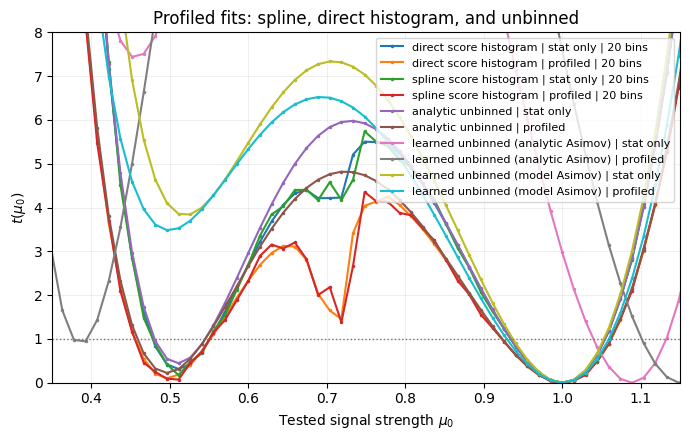

,mu,systematics,q_direct,mu_hat_direct,q_spline,mu_hat_spline,delta_q,is_spline_anchor
0,0.200000,False,290.311376,1.0,290.311376,1.000000,0.000000e+00,True
1,0.200000,True,185.400301,1.0,185.400301,1.000000,-3.382183e-12,True
2,0.214815,False,241.759325,1.0,241.860627,1.000403,1.013016e-01,False
3,0.214815,True,154.254978,1.0,154.027801,1.001349,-2.271766e-01,False
4,0.229630,False,200.609035,1.0,200.477758,0.999921,-1.312762e-01,False
...,...,...,...,...,...,...,...,...
159,1.370370,True,61.789244,1.0,61.769001,1.000135,-2.024263e-02,False
160,1.385185,False,92.217332,1.0,92.287132,0.999757,6.979987e-02,False
161,1.385185,True,68.229283,1.0,68.348960,0.999479,1.196765e-01,False
162,1.400000,False,101.535420,1.0,101.535420,1.000000,-1.864464e-11,True


Actual unique spline anchors: 3602
Largest spline/direct test-statistic difference on the scan: 0.7500898349081746
Largest difference at evaluated non-anchor points: 0.7500898349081746


In [9]:
display(splines["scans"])
SCAN_XLIM = (0.35, 1.15)  # e.g. (0.35, 1.15); None keeps the default x-axis range.
SCAN_YLIM = (0,8)  # e.g. (0, 8); None keeps the default y-axis range.
plot_scans(splines["scans"], "Profiled fits: spline, direct histogram, and unbinned", "05_profiled_scans.pdf",
           xlim=SCAN_XLIM, ylim=SCAN_YLIM)
comparison = splines["comparison"]
display(comparison)
print("Actual unique spline anchors:", len(splines["spline"].etas))
print("Largest spline/direct test-statistic difference on the scan:", comparison["delta_q"].abs().max())
off_grid = comparison.loc[~comparison["is_spline_anchor"]]
if len(off_grid):
    print("Largest difference at evaluated non-anchor points:", off_grid["delta_q"].abs().max())
else:
    print("All evaluated scan points are spline anchors; their agreement does not test interpolation between anchors.")
    print("Inspect the midpoint template-validation table and additional off-grid likelihood checks.")

### Read the comparisons separately

- **Spline vs direct histogram:** tests amortization of the moving
  observable. The midpoint template comparison evaluates interpolation;
  scan points flagged as spline anchors check agreement at stored knots.
- **Coarse vs fine direct histograms:** tests finite binning.
- **Binned nuisance interpolation vs integrated unbinned interpolation:**
  tests the distinction between two morphing prescriptions.
- **Learned vs analytical unbinned:** tests ratio estimation.
- **Score histograms vs the full unbinned model:** includes the effects
  of scalar compression, particularly when \(\alpha_{NI}\) is profiled.

A scalar \(\mu\)-score at \(\alpha_{NI}=0\) does not automatically
preserve all profiled information. A joint score vector, or a suitable
efficient score, is a natural extension. This example measures the
agreement obtained by the requested scalar construction.

Notebook 4's \(\sigma_\mu(\eta)\) and \(\hat\mu(\eta)\) study uses the
same frozen-fit convention. Those local widths help explain sensitivity
near the generating minimum; this complete profile scan also reveals
the secondary minimum and any disconnected low-test-statistic regions.

In [8]:
print("All stages finished. Results are stored under:", ROOT)
print("Use a new RUN_NAME for a changed configuration or a fresh statistical study.")
for key, value in splines.items():
    if key not in ("scans", "yields", "validation", "spline"):
        print(key)
        display(value)

All stages finished. Results are stored under: /content/drive/MyDrive/poodemo/runs/paper-nearby-v2
Use a new RUN_NAME for a changed configuration or a fresh statistical study.
physical_yields


,mu,eta,bin,yield_value
0,0.2,1.0,0,0.000000
1,0.2,1.0,1,0.000000
2,0.2,1.0,2,0.000000
3,0.2,1.0,3,0.000000
4,0.2,1.0,4,537619.620040
...,...,...,...,...
1635,1.4,1.0,15,205042.726886
1636,1.4,1.0,16,267015.518839
1637,1.4,1.0,17,256055.315244
1638,1.4,1.0,18,38542.598759


morph_comparison


,eta,alpha_NI,l1_relative_difference,nll_difference
0,0.200000,-1.0,5.384931e-16,-3.055902e-10
1,0.200000,-0.5,1.814863e-05,1.556363e+00
2,0.200000,0.5,2.510891e-05,-5.515859e+00
3,0.200000,1.0,6.691192e-16,8.440111e-10
4,0.200000,1.5,1.523410e-04,9.851110e+01
5,0.807407,-1.0,5.681307e-16,-3.346941e-10
6,0.807407,-0.5,2.109673e-05,-2.938484e+00
7,0.807407,0.5,2.261177e-05,2.397600e+00
8,0.807407,1.0,7.278732e-16,9.022187e-10
9,0.807407,1.5,1.539064e-04,-4.336216e+01


comparison


,mu,systematics,q_direct,mu_hat_direct,q_spline,mu_hat_spline,delta_q,is_spline_anchor
0,0.200000,False,290.311376,1.0,290.311376,1.000000,0.000000e+00,True
1,0.200000,True,185.400301,1.0,185.400301,1.000000,-3.382183e-12,True
2,0.214815,False,241.759325,1.0,241.860627,1.000403,1.013016e-01,False
3,0.214815,True,154.254978,1.0,154.027801,1.001349,-2.271766e-01,False
4,0.229630,False,200.609035,1.0,200.477758,0.999921,-1.312762e-01,False
...,...,...,...,...,...,...,...,...
159,1.370370,True,61.789244,1.0,61.769001,1.000135,-2.024263e-02,False
160,1.385185,False,92.217332,1.0,92.287132,0.999757,6.979987e-02,False
161,1.385185,True,68.229283,1.0,68.348960,0.999479,1.196765e-01,False
162,1.400000,False,101.535420,1.0,101.535420,1.000000,-1.864464e-11,True


n_bins


20

### Further experiments

Increase the integration statistics to test numerical stability; widen
the scan to expose interference effects; compare a fixed \(\eta=\mu_*\)
score with the moving score; or add nuisance-score components. An
interval-coverage study would require genuine pseudo-experiments and
calibration of the chosen statistic, beyond these Asimov comparisons.